# 04 — Method Validation

This notebook shows the tests to decide which version of DMD to use for the analysis. This was done by injecting a synthetic standing mode of known $f$ and $\gamma$ into real measured turbulence from the discharge used in the main analysis (instead of using a Gaussian idealisation). Three estimators were compared:

1. **BOP-DMD** a.k.a. optimised DMD (since used without bagging) — the production configuration, calling the same `rank_selection`, `local_fourier_seed` and two-pass `fit_bopdmd` used everywhere else in this analysis.
2. **Hankel DMD** — delay embedding ($d = 20$) plus exact DMD, taking its rank from the same Gavish-Donoho threshold.
3. **Fourier** — a non-DMD baseline, so the comparison isn't "DMD versus nothing": an interpolated periodogram peak for $f$, and a Hilbert-envelope decay fit for $\gamma$.

The fits are done at a window length of 0.5 ms.

Two deliberate departures from production isolate *estimation* accuracy from *detection*: the target frequency is the known injected value rather than a Viterbi anchor, and the candidate is the pole nearest that frequency rather than the highest-energy pole in a band.

In [1]:
# Imports

import sys, os
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from src import config as cfg
from src.math_helpers import load_data
from src.validation import (
    prepare_host_chunks, standing_envelope, inject_standing,
    run_snr_sweep, summarise, latex_table
)

## 1. Host Turbulence and the Injected Mode

The host data is a 20 ms stretch of the same discharge, gain-calibrated and band-passed to `325 - 375 kHz`, a band with no coherent mode in it. It is cut into independent 0.5 ms windows, one fit per window.

The injected pattern has 3 antinodes and 2 nodes across the 32 channels, mimicking the alternating-sign radial structure of an eigenmode. SNR is defined as the injected wave's standard deviation relative to the host's.

In [2]:
ctx = load_data()
chunks, t_ch = prepare_host_chunks(ctx)
env = standing_envelope(ctx['n_ch'])

print(f"{len(chunks)} independent chunks of {chunks[0].shape}, "
      f"{t_ch[-1]*1e3:.2f} ms each; band {cfg.VAL_BAND[0]/1e3:.0f}-{cfg.VAL_BAND[1]/1e3:.0f} kHz")
print(f"truth: f = {cfg.VAL_F_INJ/1e3:.1f} kHz, gamma = {-cfg.VAL_GAMMA_INJ:+.1f} /s")
print(f"decay across the window: amplitude falls to {np.exp(-cfg.VAL_GAMMA_INJ*t_ch[-1]):.3f} "
      f"of initial ({cfg.VAL_GAMMA_INJ*t_ch[-1]:.2f} e-foldings)")

39 independent chunks of (32, 1000), 0.50 ms each; band 325-375 kHz
truth: f = 350.0 kHz, gamma = -900.0 /s
decay across the window: amplitude falls to 0.638 of initial (0.45 e-foldings)


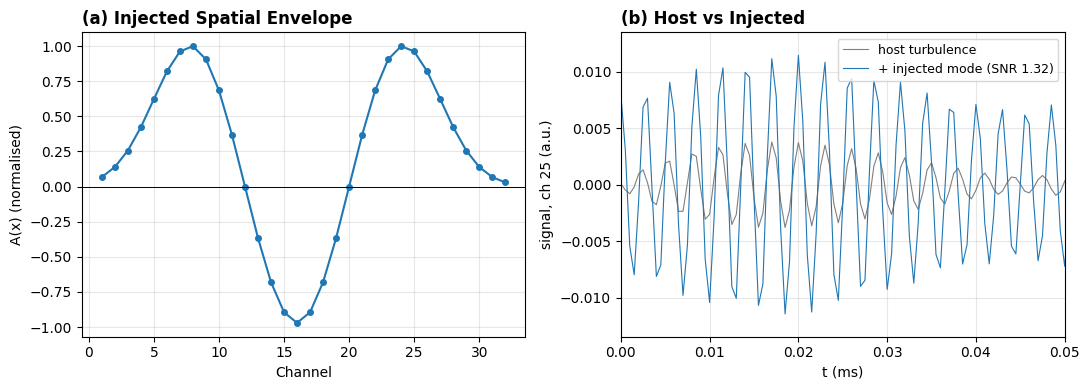

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Spatial envelope A(x) of the injected mode
ax[0].plot(np.arange(1, ctx['n_ch'] + 1), env, 'o-', ms=4, color='tab:blue')
ax[0].axhline(0, color='k', lw=0.7)
ax[0].set_xlabel('Channel')
ax[0].set_ylabel('A(x) (normalised)')
ax[0].set_title('(a) Injected Spatial Envelope', loc='left', fontweight='bold')
ax[0].grid(alpha=0.3)

# One channel of one window, before and after injection at the mid-sweep SNR
snr_demo = cfg.VAL_SNRS[len(cfg.VAL_SNRS) // 2]
inj = inject_standing(chunks[0], t_ch, cfg.VAL_F_INJ, snr_demo, envelope=env)

ax[1].plot(t_ch * 1e3, chunks[0][cfg.CH_REF - 1], lw=0.8, color='grey', label='host turbulence')
ax[1].plot(t_ch * 1e3, inj[cfg.CH_REF - 1], lw=0.8, color='tab:blue',
           label=f'+ injected mode (SNR {snr_demo:.2f})')
ax[1].set_xlim(0, 0.05)
ax[1].set_xlabel('t (ms)')
ax[1].set_ylabel(f'signal, ch {cfg.CH_REF} (a.u.)')
ax[1].set_title('(b) Host vs Injected', loc='left', fontweight='bold')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 2. SNR Sweep

Every chunk is fitted at every SNR by all three estimators. The spread across chunks is the window-to-window scatter of the estimator.

The full sweep takes ~18 minutes, so it is cached to `out/`.

In [4]:
sweep_cache = os.path.join(cfg.OUT, 'discharge1_validation_sweep.npz')
D = run_snr_sweep(ctx, chunks, t_ch, checkpoint_path=sweep_cache)
S = summarise(D)

f_inj, g_true = float(D['f_inj']), -float(D['gamma_inj'])
print(f"ranks used -- BOP-DMD {np.nanmedian(D['rank_bop']):.0f}, "
      f"Hankel {np.nanmedian(D['rank_han']):.0f}")

ranks used -- BOP-DMD 12, Hankel 16


## 3. Recovery of $f$ and $\gamma$ against SNR

Frequency is shown as an RMS error. The extracted gamma value is shown with +/- 1 standard deviation across the windows.

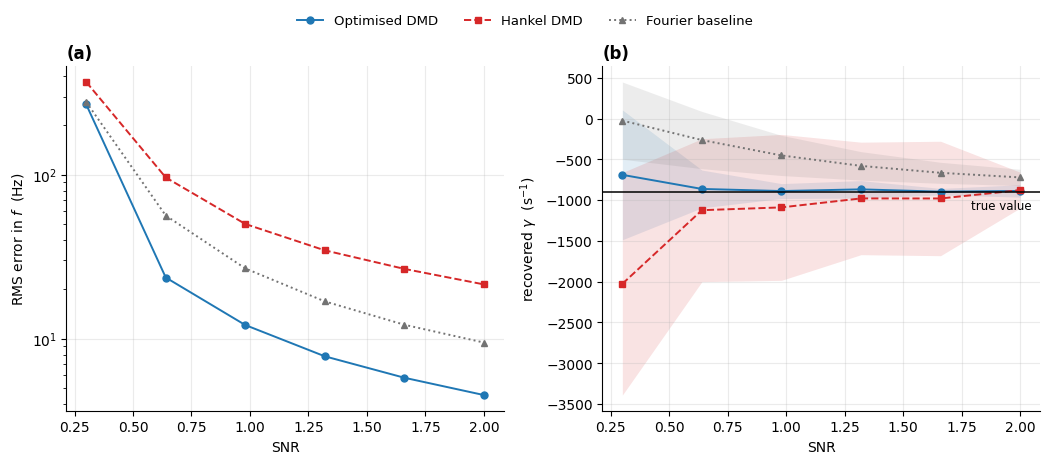

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.4))

# BOP-DMD is labelled "Optimised DMD" here.
SERIES = [('bop', 'Optimised DMD', 'tab:blue', 'o', '-'),
          ('han', 'Hankel DMD', 'tab:red', 's', '--'),
          ('fou', 'Fourier baseline', '0.45', '^', ':')]

# (a) RMS error in frequency
handles = []
for tag, lab, col, mk, ls in SERIES:
    h, = ax[0].plot(D['snrs'], S[tag]['f_rms'], marker=mk, ls=ls, color=col, ms=5, lw=1.4, label=lab)
    handles.append(h)
ax[0].set_yscale('log')
ax[0].set_xlabel('SNR')
ax[0].set_ylabel(r'RMS error in $f$  (Hz)')
ax[0].set_title('(a)', loc='left', fontweight='bold')

# (b) recovered growth rate, shaded band = +/- 1 sd across windows
for tag, lab, col, mk, ls in SERIES:
    m, sd = g_true + S[tag]['g_bias'], S[tag]['g_sd']
    ax[1].plot(D['snrs'], m, marker=mk, ls=ls, color=col, ms=5, lw=1.4)
    ax[1].fill_between(D['snrs'], m - sd, m + sd, color=col, alpha=0.13, lw=0)

ax[1].axhline(g_true, color='k', lw=1.1)
from matplotlib.transforms import blended_transform_factory
tr = blended_transform_factory(ax[1].transAxes, ax[1].transData)
ax[1].text(0.98, g_true - 90, 'true value', transform=tr, ha='right', va='top', fontsize=8.5)
ax[1].set_xlabel('SNR')
ax[1].set_ylabel(r'recovered $\gamma$  (s$^{-1}$)')
ax[1].set_title('(b)', loc='left', fontweight='bold')

for a_ in ax:
    a_.grid(alpha=0.25)
    a_.spines[['top', 'right']].set_visible(False)

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=3, fontsize=9.5, frameon=False)
fig.tight_layout()
plt.show()

## 4. Report Table

In [6]:
print(f"{'SNR':>5s} | {'RMS error in f (Hz)':^28s} | {'gamma bias (1/s) +- sd':^42s}")
print(f"{'':>5s} | {'Fourier':>9s} {'Hankel':>9s} {'BOP-DMD':>8s} | "
      f"{'Fourier':>13s} {'Hankel':>14s} {'BOP-DMD':>13s}")
for i, s in enumerate(D['snrs']):
    print(f'{s:5.2f} | ' + ' '.join(f"{S[t]['f_rms'][i]:9.1f}" for t in ('fou', 'han', 'bop'))
          + ' | ' + '  '.join(f"{S[t]['g_bias'][i]:+5.0f}+-{S[t]['g_sd'][i]:<6.0f}"
                              for t in ('fou', 'han', 'bop')))

  SNR |     RMS error in f (Hz)      |           gamma bias (1/s) +- sd          
      |   Fourier    Hankel  BOP-DMD |       Fourier         Hankel       BOP-DMD
 0.30 |     278.0     368.3     268.7 |  +874+-473     -1126+-1363     +210+-796   
 0.64 |      56.4      96.2      23.6 |  +636+-351      -224+-876       +37+-231   
 0.98 |      26.8      50.1      12.1 |  +447+-246      -189+-894       +11+-91    
 1.32 |      16.9      34.6       7.8 |  +319+-175       -79+-689       +32+-107   
 1.66 |      12.2      26.6       5.8 |  +234+-129       -80+-701        +3+-40    
 2.00 |       9.5      21.4       4.5 |  +178+-100       +22+-220       +12+-76    
